In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "order_id": range(1, 201),
    "date": pd.date_range(start="2024-01-01", periods=200, freq="D"),
    "region": np.random.choice(["North", "South", "East", "West"], 200),
    "product": np.random.choice(["Laptop", "Phone", "Tablet", "Headphones"], 200),
    "quantity": np.random.randint(1, 5, 200),
    "price": np.random.randint(500, 2000, 200)
}

df = pd.DataFrame(data)
df.to_csv("sales.csv", index=False)

df.head()

,order_id,date,region,product,quantity,price
0,1,2024-01-01,East,Tablet,4,1376
1,2,2024-01-02,West,Headphones,4,1491
2,3,2024-01-03,North,Tablet,3,1383
3,4,2024-01-04,East,Laptop,1,1873
4,5,2024-01-05,East,Headphones,4,546


In [6]:
import sqlite3

conn = sqlite3.connect("sales.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

print("Data loaded into SQL!")

Data loaded into SQL!


In [7]:
query = """
SELECT region, SUM(quantity * price) AS revenue
FROM sales
GROUP BY region
ORDER BY revenue DESC;
"""

result = pd.read_sql(query, conn)
result

,region,revenue
0,West,202281
1,East,167210
2,North,161390
3,South,145923


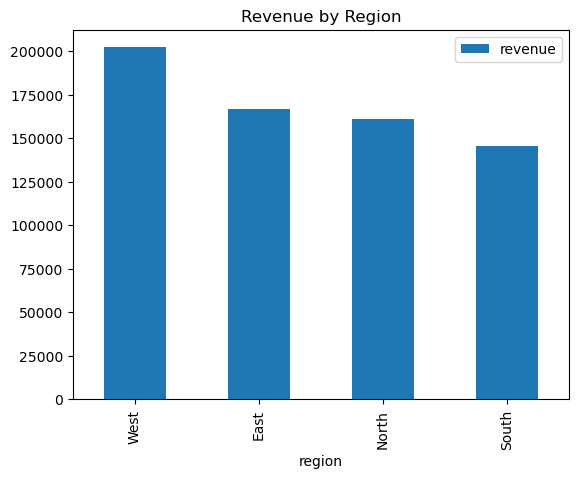

In [8]:
import matplotlib.pyplot as plt

result.plot(x="region", y="revenue", kind="bar")
plt.title("Revenue by Region")
plt.show()

In [9]:
query_month = """
SELECT strftime('%Y-%m', date) AS month,
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY month
ORDER BY month;
"""

df_month = pd.read_sql(query_month, conn)
df_month

,month,revenue
0,2024-01,103787
1,2024-02,115020
2,2024-03,97916
3,2024-04,97488
4,2024-05,95616
5,2024-06,97652
6,2024-07,69325


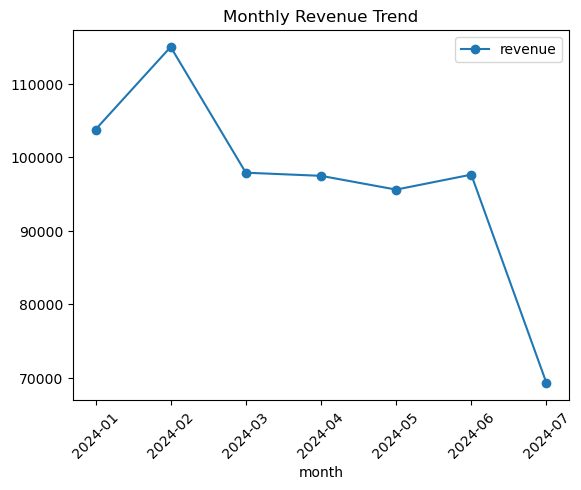

In [10]:
df_month.plot(x="month", y="revenue", kind="line", marker='o')
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

In [11]:
query_products = """
SELECT product, SUM(quantity) AS total_sold
FROM sales
GROUP BY product
ORDER BY total_sold DESC;
"""

df_products = pd.read_sql(query_products, conn)
df_products

,product,total_sold
0,Headphones,164
1,Tablet,134
2,Laptop,111
3,Phone,102


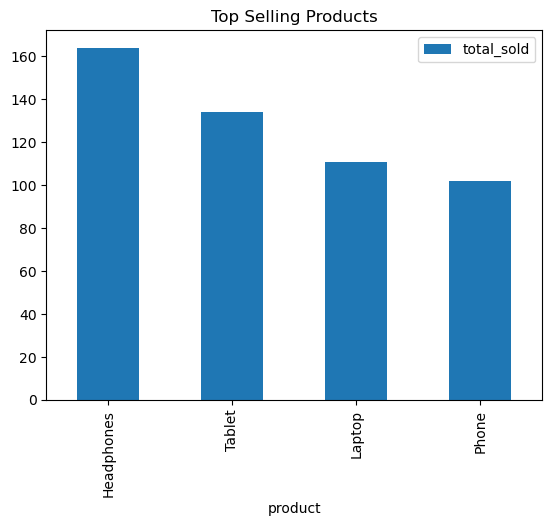

In [12]:
df_products.plot(x="product", y="total_sold", kind="bar")
plt.title("Top Selling Products")
plt.show()

In [13]:
query_avg = """
SELECT region,
       AVG(quantity * price) AS avg_order_value
FROM sales
GROUP BY region;
"""

df_avg = pd.read_sql(query_avg, conn)
df_avg

,region,avg_order_value
0,East,3096.481481
1,North,3508.478261
2,South,3172.239130
3,West,3745.944444


# Sales Data Analysis Dashboard

## Objective
Analyze sales data using SQL and Python to extract business insights.

## Key Questions
- Which region generates the most revenue?
- What are monthly sales trends?
- Which products sell the most?

In [14]:
plt.savefig("revenue_by_region.png")

<Figure size 640x480 with 0 Axes>

In [15]:
query = """
SELECT product,
       SUM(quantity * price) AS revenue,
       RANK() OVER (ORDER BY SUM(quantity * price) DESC) AS rank
FROM sales
GROUP BY product;
"""

df_rank = pd.read_sql(query, conn)
df_rank

,product,revenue,rank
0,Headphones,222190,1
1,Tablet,167636,2
2,Laptop,144230,3
3,Phone,142748,4


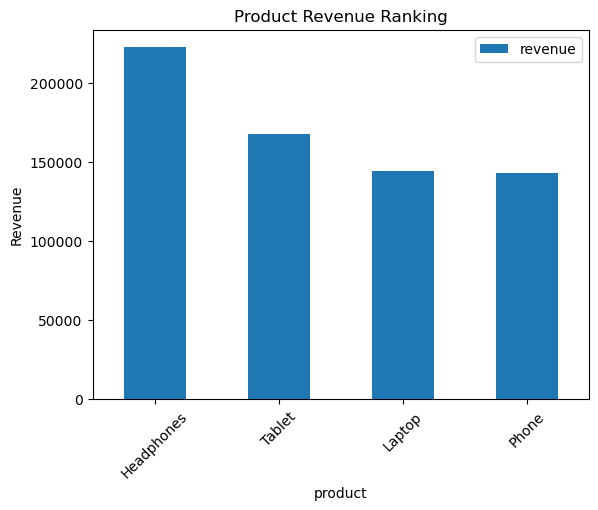

In [16]:
import matplotlib.pyplot as plt

df_rank.sort_values("revenue", ascending=False).plot(
    x="product", y="revenue", kind="bar"
)

plt.title("Product Revenue Ranking")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## Insights

- Product X generates the highest revenue
- Lower-ranked products contribute significantly less to total sales
- Revenue distribution indicates possible focus areas for business optimization

In [17]:
plt.savefig("product_ranking.png")

<Figure size 640x480 with 0 Axes>